In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/FIAP/Machine Learning & Data Science/Datasets/dataset_elasticidade_supermercado.csv')

In [ ]:
df['Categoria'].value_counts()

,count
Categoria,
Açougue,300
Frios e laticínios,300
Adega e bebidas,300
Higiene e limpeza,300
Hortifruti e mercearia,300
Padaria,300
Enlatados,300
Cereais,300
Congelados,300


In [ ]:
df.sample(3)

,Categoria,Preco,Demanda
2663,Congelados,10.456424,33.422255
249,Açougue,36.962942,130.831336
2677,Congelados,15.302617,34.360416


In [ ]:
def elasticidade(df, categoria):
    sub_df = df[df['Categoria'] == categoria].copy()
    sub_df = sub_df[(sub_df['Preco'] > 0) & (sub_df['Demanda'] > 0)]
    sub_df['log_preco'] = np.log(sub_df['Preco'])
    sub_df['log_demanda'] = np.log(sub_df['Demanda'])

    X = sm.add_constant(sub_df['log_preco'])
    y = sub_df['log_demanda']
    model = sm.OLS(y, X).fit()

    print(f"--- {categoria} ---")
    #print(model.summary())
    print(f"Elasticidade-preço estimada: {model.params['log_preco']:.3f}\n")

In [ ]:
elasticidade(df, 'Frios e laticínios')

--- Frios e laticínios ---
Elasticidade-preço estimada: 0.186



In [ ]:
elasticidade(df, 'Adega e bebidas')

--- Adega e bebidas ---
Elasticidade-preço estimada: -0.641



In [ ]:
elasticidade(df, 'Cereais')

--- Cereais ---
Elasticidade-preço estimada: -1.626



In [ ]:
categorias = df['Categoria'].unique()
for categoria in categorias:
    elasticidade(df, categoria)

--- Açougue ---
Elasticidade-preço estimada: -0.588

--- Frios e laticínios ---
Elasticidade-preço estimada: 0.186

--- Adega e bebidas ---
Elasticidade-preço estimada: -0.641

--- Higiene e limpeza ---
Elasticidade-preço estimada: 0.213

--- Hortifruti e mercearia ---
Elasticidade-preço estimada: -0.915

--- Padaria ---
Elasticidade-preço estimada: -1.041

--- Enlatados ---
Elasticidade-preço estimada: 0.281

--- Cereais ---
Elasticidade-preço estimada: -1.626

--- Congelados ---
Elasticidade-preço estimada: -1.444

--- Papelaria ---
Elasticidade-preço estimada: -0.498



In [ ]:
def plot_loglog_scatter(df, categoria):
    sub_df = df[df['Categoria'] == categoria].copy()
    sub_df = sub_df[(sub_df['Preco'] > 0) & (sub_df['Demanda'] > 0)]
    sub_df['log_preco'] = np.log(sub_df['Preco'])
    sub_df['log_demanda'] = np.log(sub_df['Demanda'])

    plt.figure(figsize=(8,6))
    sns.scatterplot(x='log_preco', y='log_demanda', data=sub_df, label=categoria, alpha=0.6)
    sns.regplot(x='log_preco', y='log_demanda', data=sub_df, scatter=False, color='red', label='Regressão')
    plt.title(f'Elasticidade-preço para {categoria}')
    plt.xlabel('log(Preço)')
    plt.ylabel('log(Demanda)')
    plt.legend()
    plt.show()

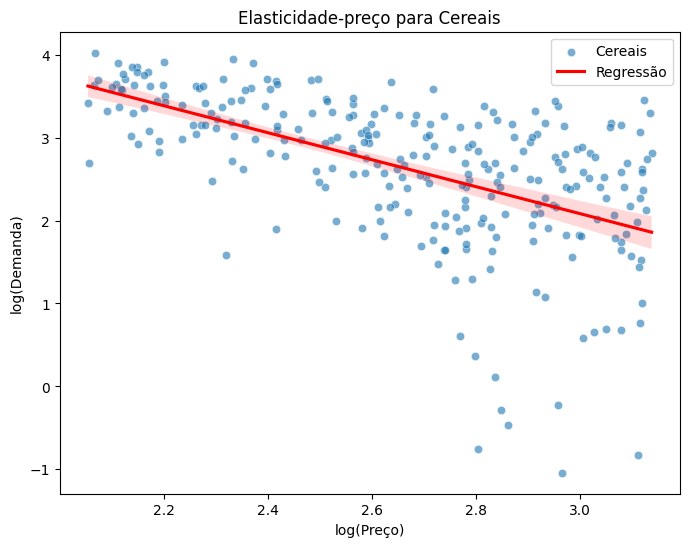

In [ ]:
plot_loglog_scatter(df, 'Cereais')

In [ ]:
def calcular_elasticidade(df, categorias):
    elasticidades = []
    for cat in categorias:
        sub_df = df[df["Categoria"] == cat].copy()
        sub_df = sub_df[(sub_df["Preco"] > 0) & (sub_df["Demanda"] > 0)]
        sub_df["log_preco"] = np.log(sub_df["Preco"])
        sub_df["log_demanda"] = np.log(sub_df["Demanda"])

        X = sm.add_constant(sub_df["log_preco"])
        y = sub_df["log_demanda"]
        model = sm.OLS(y, X).fit()
        elasticidades.append((cat, model.params["log_preco"]))

    return pd.DataFrame(elasticidades, columns=["categoria", "Elasticidade"])

In [ ]:
df_elasticidade = calcular_elasticidade(df, categorias)

<ipython-input-36-1fce615ffd36>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_elasticidade, x="categoria", y="Elasticidade", palette="mako")


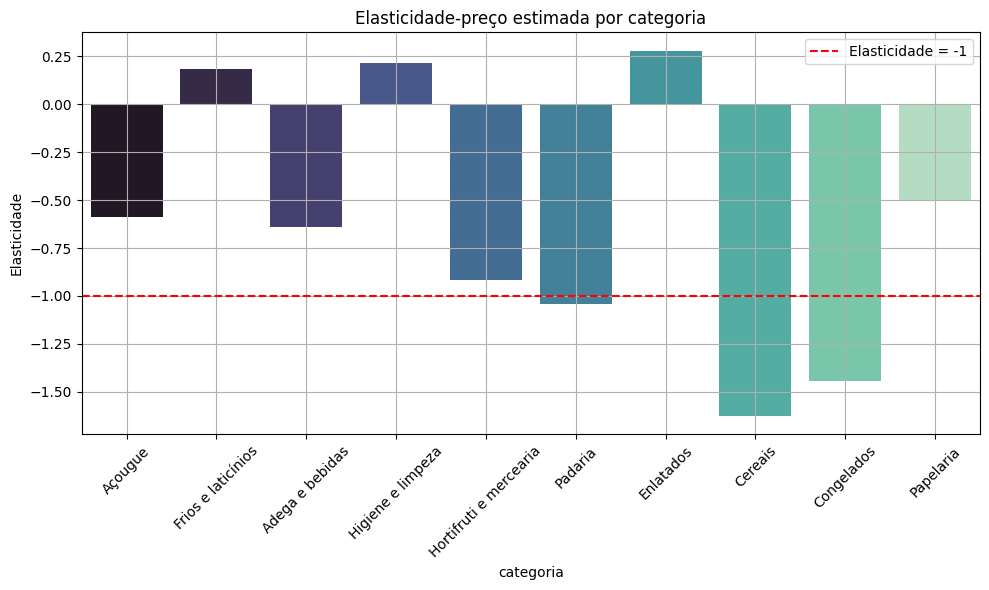

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_elasticidade, x="categoria", y="Elasticidade", palette="mako")
plt.axhline(-1, color="red", linestyle="--", label="Elasticidade = -1")
plt.title("Elasticidade-preço estimada por categoria")
plt.ylabel("Elasticidade")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()